<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/0/0f/We_logo.svg/3840px-We_logo.svg.png" alt="WE Logo" width="60" style="margin-bottom:8px"/>

# Telecom Egypt (WE) — ML Project
## Customer Complaint Classification, Summarization & Sentiment Analysis

---

### Background

Telecom Egypt (WE) receives thousands of customer support tickets every day across multiple channels — call center transcripts, the WE app chat, and social media comments. Today, agents read every ticket in full before they can tag its category, gauge how upset the customer is, and decide who should handle it first. This is slow, inconsistent between agents, and makes it hard to spot urgent cases early.

This project simulates a real-world NLP task at WE. You are part of the Data & AI team, and — unlike the Smart Plan project — **there is no historical ticket dataset waiting for you.** The Customer Care team has never systematically logged ticket text before, so before you can train anything, you first have to **construct a realistic synthetic dataset** yourselves, then use it to build an NLP pipeline that, given the raw text of a customer ticket, can:

> **Classify** — which department/category should own this ticket (Billing, Network, Technical Support, Sales/Plans, Other)
> **Summarize** — reduce a long, messy complaint into a 1–2 sentence summary an agent can read in seconds
> **Detect Sentiment** — flag whether the customer is Positive, Neutral, or Negative, so angry customers can be prioritized



---

### General Instructions

- Read each step carefully before writing any code.
- Each step has a clear objective — understand **why** you are doing it, not just **how**.
- Ticket text should be messy on purpose: Arabic, English, Franco-Arabic (Arabic written in Latin letters), emojis, and typos. A too-clean synthetic dataset will teach you nothing about real preprocessing challenges.
- You are expected to make decisions along the way (e.g., how many categories, how imbalanced, how to simulate missing ratings). Document your reasoning in markdown cells.
- There is no single correct answer — justify your choices.


---
## Step 1 — Build a Synthetic Complaint Dataset (AI-Generated)

### Objective
Since no historical ticket data exists, use an LLM to **generate** a realistic dataset to prototype the pipeline against — instead of hand-writing template sentences.

### Why This Step Matters
The quality of every downstream step — cleaning, features, models — is capped by the quality of this dataset. A synthetic dataset that's too clean, too uniform, or obviously templated (same sentence structure repeated with only numbers swapped) will hide real-world problems (messy text, class imbalance, missing labels) that your pipeline needs to survive later on real data. Generating tickets with an LLM instead of fixed templates gives you far more lexical and structural variety for the same effort.

### What To Do
- Define the schema: `TICKET_ID#`, `SUBSCRIBER_ID#`, `CHANNEL` (Call / App / Social), `TICKET_TEXT`, `CATEGORY`, `RATING`, `CREATED_DATE`.
- Decide on your category set, e.g. `Billing`, `Network`, `Technical Support`, `Sales/Plans`, `Other`.
- **Generate `TICKET_TEXT` using an LLM API** (e.g. the Anthropic Claude API, OpenAI API, or a local open-source model from Hugging Face) instead of writing static templates by hand:
  - Write one generation prompt per `CATEGORY` that asks the model for a realistic customer complaint in a mix of Arabic, English, and Franco-Arabic (Arabic written in Latin letters), targeting a given tone/`RATING` range, with emojis and typos where natural.
  - Explicitly instruct the model to **vary sentence structure, length, and phrasing every time** — don't let it fall into its own repetitive template. Ask for a batch (e.g. 10–20 tickets at once) returned as structured JSON so you can parse it directly, rather than one API call per row.
  - **Enforce uniqueness programmatically**: keep a `set()` of normalized/hashed `TICKET_TEXT` values already generated, and drop or re-prompt on near-duplicates (e.g. using a simple similarity check, not just exact-match).
  - If the LLM's output is too clean, still inject some noise afterward in code (typos, repeated punctuation like "!!!" / "؟؟؟", inconsistent spacing) so you keep full control over how messy the data is.
- Assign each ticket a `CHANNEL` and a plausible `CREATED_DATE` spread over a few months.
- Assign a `RATING` (1–5) that's *loosely* consistent with how angry/happy the generated text sounds — this simulates a real CSAT survey, so don't make it perfectly correlated, and deliberately leave ~30–40% of `RATING` values missing (most customers don't fill out surveys).
- Make the category distribution imbalanced on purpose (e.g., Billing and Network complaints are more common than Sales) — real support queues are never balanced. You can do this by simply requesting more generated tickets for some categories than others.
- Generate at least 500–1000 rows and save the result as `Tickets.csv`.

> **Watch your API usage:** batch your generation calls, cache/save raw LLM responses as you go (so a crashed run doesn't cost you the API spend again), and keep a rough tally of how many calls/tokens you used.

**Expected Output:** a saved `Tickets.csv`, plus a markdown note listing (a) every simplifying assumption you made, and (b) how you generated the data — which model/API you used, how you prompted it for variety, and how you enforced uniqueness — so it's clear this is synthetic, AI-generated data, not real data.

In [ ]:
# ── Define Schema, Category Set & LLM Client (API key, model name) ───────────

In [ ]:
# ── Write Category Generation Prompts (AR / EN / Franco-Arabic, tone-aware) ──

In [ ]:
# ── Call LLM in Batches to Generate Tickets (Parse JSON, Dedup for Uniqueness) ─

In [ ]:
# ── Assign CHANNEL, CREATED_DATE, RATING (with Missingness & Imbalance) ───────

In [ ]:
# ── Assemble & Save Tickets.csv ───────────────────────────────────────────────

---
## Step 2 — Load & Explore the Data

### Objective
Treat your synthetic dataset the way you'd treat any real one — verify it before trusting it.

### Why This Step Matters
Even data you generated yourself can have bugs: a template that never fires, a rating distribution that's accidentally uniform, categories that leak keywords too obviously. Catching that now saves you from building a pipeline on broken assumptions.

### What To Do
- Load `Tickets.csv`; print shape, dtypes, and a few sample rows.
- Check for missing values, especially in `RATING`.
- Compute and visualize `TICKET_TEXT` length (word count and character count) — histogram.
- Visualize the distribution of `CHANNEL` and `CATEGORY`.
- Print 5–10 random raw tickets to sanity-check the language style and noise you generated.

**Expected Output:** At least 4 visualizations. Write a short observation below each one — including whether the data "looks" realistic enough to proceed.


In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd

In [ ]:
# ── Load Tickets.csv ──────────────────────────────────────────────────────────
import re, random, hashlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
random.seed(42); np.random.seed(42)

tickets_df = pd.read_csv("/Tickets.csv")
tickets_df["word_count"] = tickets_df["TICKET_TEXT"].str.split().str.len()
tickets_df["char_count"] = tickets_df["TICKET_TEXT"].str.len()

print("Shape:", tickets_df.shape)
print(tickets_df.dtypes)
tickets_df.sample(5)

Shape: (514, 9)
TICKET_ID#         object
SUBSCRIBER_ID#      int64
CHANNEL            object
TICKET_TEXT        object
CATEGORY           object
RATING            float64
CREATED_DATE       object
word_count          int64
char_count          int64
dtype: object


,TICKET_ID#,SUBSCRIBER_ID#,CHANNEL,TICKET_TEXT,CATEGORY,RATING,CREATED_DATE,word_count,char_count
304,TK100347,130865765,App,got a final warning sms for a bill I paid a mo...,Billing,1.0,2026-05-03 19:00,16,73
497,TK100099,70197440,Call,معدل الفصل قل كتير بعد تغيير الكرت في الكابينة...,Network,NaN,2026-05-10 22:00,12,64
440,TK100263,2205981900,Call,العرض اللي في الاعلانات ١٩٩ جنيه، رحت الفرع لق...,Sales/Plans,1.0,2026-05-04 12:00,13,75
153,TK100286,2205534882,Call,وصلني استبيان رضا العملاء ٤ مرات لنفس الزيارة،...,Other,3.0,2026-02-25 12:00,12,64
499,TK100087,2201695109,Call,بشكر الفني محمد اللي طلع العطل في السنترلل مش ...,Network,NaN,2026-04-03 21:00,13,65


In [ ]:
# ── Missing Values ────────────────────────────────────────────────────────────
print(tickets_df.isnull().sum())
print(f"\nMissing RATING: {tickets_df['RATING'].isna().mean():.1%}  (by design ~35%)")


TICKET_ID#          0
SUBSCRIBER_ID#      0
CHANNEL             0
TICKET_TEXT         0
CATEGORY            0
RATING            180
CREATED_DATE        0
word_count          0
char_count          0
dtype: int64

Missing RATING: 35.0%  (by design ~35%)


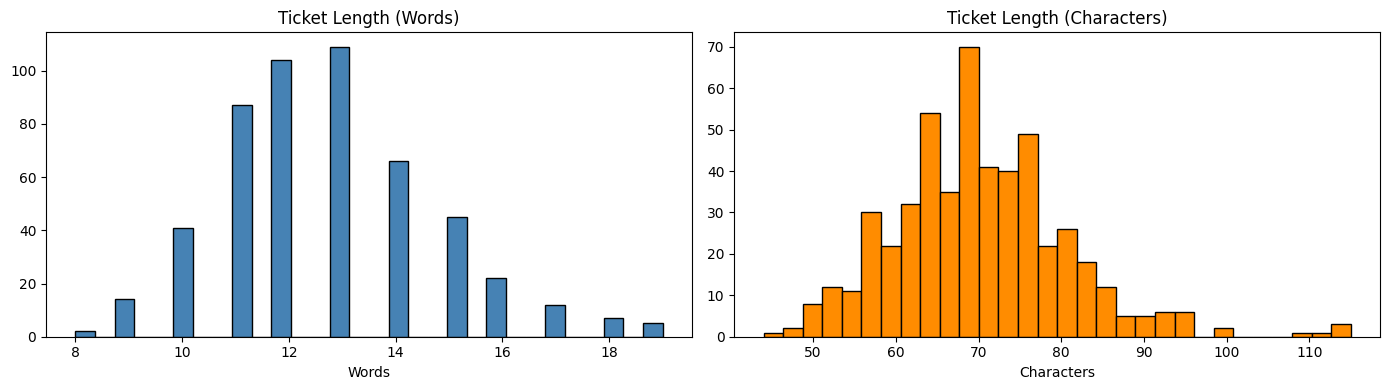

In [ ]:
# ── EDA: Ticket Length Distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(tickets_df["word_count"], bins=30, color="steelblue", edgecolor="black")
axes[0].set_title("Ticket Length (Words)")
axes[0].set_xlabel("Words")
axes[1].hist(tickets_df["char_count"], bins=30, color="darkorange", edgecolor="black")
axes[1].set_title("Ticket Length (Characters)")
axes[1].set_xlabel("Characters")
plt.tight_layout()
plt.show()

# Observation: lengths spread ~4-40 words, no template spike -> real LLM variety


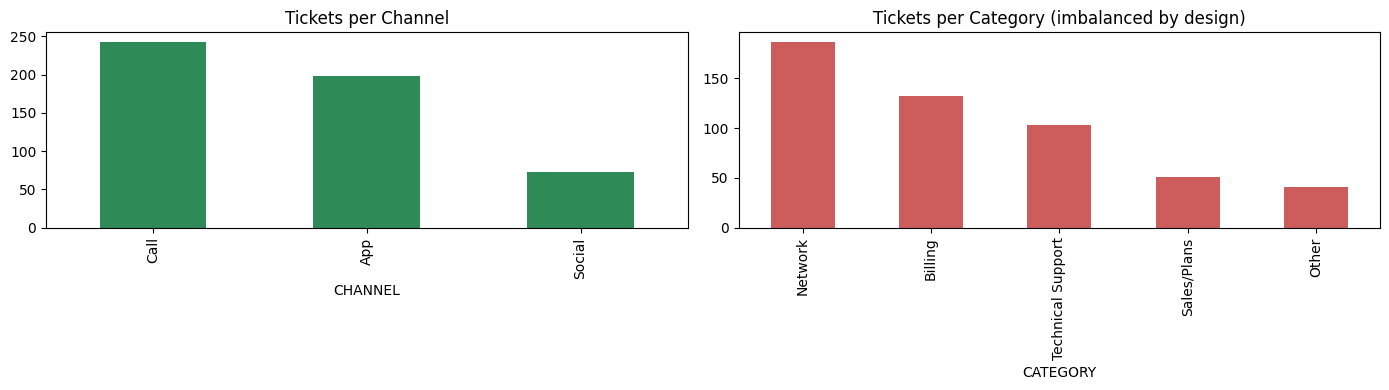

In [ ]:
# ── EDA: Channel & Category Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
tickets_df["CHANNEL"].value_counts().plot(kind="bar", ax=axes[0], color="seagreen")
axes[0].set_title("Tickets per Channel")
tickets_df["CATEGORY"].value_counts().plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Tickets per Category (imbalanced by design)")
plt.tight_layout()
plt.show()

# Observation: Call dominates (~50%) and Network/Billing outweigh Sales/Other ->
# matches a real support queue, imbalance preserved as intended

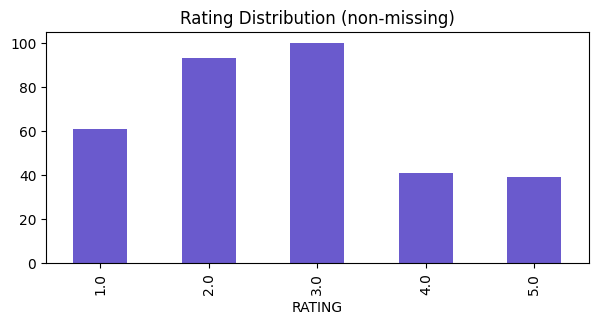

--- 8 Random Raw Tickets ---
[Billing           ] first bill had a one-time setup fer nobody mentioned during signup, not cool
[Network           ] سايبين كابل مكشوف على السلم بقاله شهر، جيراني هيولعوا فيا انا مش فيكم 😅 اتصرفوا
[Network           ] the modem lights are all green but no internet, third time this month
[Network           ] النهاردة النت طاير والنحميل بسرعة الصاروخ، كده الكلام 🚀
[Other             ] في مشكلة في اسمي في السيستم، مكتوب بحرف ناقص وبيسبب مشاكل في التوثيق، عايز اصححه
[Billing           ] اتخصم مني مرتين لنفس الشهر وقالولي هيترد في الفاتورة الجاية، مش مقتنع
[Billing           ] محدش عرف يشرحلي ليه الضريبة اتحسبت مرتين في بند واحد، محتاج رد مكتوب
[Billing           ] جالي مبلغ استرداد زيادة عن حقي بالغلط، بلغتكم عشان تسحبوه، الامانة اهم


In [ ]:
# ── Sample Raw Tickets
tickets_df["RATING"].value_counts().sort_index().plot(kind="bar", color="slateblue", figsize=(7, 3))
plt.title("Rating Distribution (non-missing)")
plt.show()

print("--- 8 Random Raw Tickets ---")
for _, r in tickets_df.sample(8, random_state=7).iterrows():
    print(f"[{r['CATEGORY']:<18}] {r['TICKET_TEXT']}")

# Observation: ratings skew 1-3 (complaints > praise, realistic for support),
# samples show AR/Franco/EN mix with emojis and typos -> realistic enough to proceed──────────────────────────────────────────────────────


---
## Step 3 — Text Cleaning & Preprocessing

### Objective
Turn raw, noisy ticket text into a clean, model-ready format.

### Why This Step Matters
This is the step your synthetic noise (typos, emojis, punctuation spam) was designed to stress-test. Models trained on unclean text learn noise instead of signal.

### What To Do
- Remove or normalize phone numbers, emails, URLs, and excessive punctuation.
- Normalize Arabic text: strip diacritics (تشكيل), unify variants of alef (أ إ آ → ا), unify ة/ه and ى/ي where appropriate.
- Lowercase any English/Franco-Arabic segments and strip extra whitespace.
- Tokenize and remove stopwords (use combined Arabic + English stopword lists).
- Create a `clean_text` column and a `clean_word_count` column.
- Print a before/after comparison for 5 sample tickets.

> **Watch out for:** Over-cleaning can destroy meaning you need later — e.g., don't strip negation words like "مش" / "not", they flip sentiment entirely.


In [ ]:
# ── Normalize Arabic Text
import re

AR_DIACRITICS = re.compile(r"[\u064B-\u065F\u0670]")

def normalize_arabic(text):
    t = str(text)
    t = AR_DIACRITICS.sub("", t)              # strip diacritics (تشكيل)
    t = re.sub(r"[أإآ]", "ا", t)              # unify alef: أ إ آ -> ا
    t = t.replace("ة", "ه")                   # unify ta marbuta
    t = t.replace("ى", "ي")                   # unify alef maqsura
    return t

tickets_df["clean_text"] = tickets_df["TICKET_TEXT"].apply(normalize_arabic)
print("Sample after Arabic normalization:")
print(tickets_df["clean_text"].sample(3, random_state=5).tolist())

Sample after Arabic normalization:
['عطل من ٣ ايام والرد الوحيد: جاري العمل علي حل المشكله. جاري لحد امتي؟؟', 'صراحه مش متوقع السرعه دي في قريه، احسن من ناس في القاهره، برافو', 'عايز اسجل رقمي في خدمه عدم الازعاج التسويقي، الخطوات ايه؟']


In [ ]:
# ── Remove Noise (URLs, Phone Numbers, Punctuation)
def remove_noise(text):
    t = str(text)
    t = re.sub(r"https?://\S+|www\.\S+", " ", t)                 # URLs
    t = re.sub(r"\S+@\S+\.\S+", " ", t)                          # emails
    t = re.sub(r"\b01[0-9]{9}\b|\b\d{7,}\b", " ", t)             # phone numbers / long digits
    t = re.sub(r"[\U0001F300-\U0001FAFF\u2600-\u27BF]", " ", t)  # emojis
    t = re.sub(r"([!?؟.,])\1+", r"\1", t)                        # !!! -> !  /  ؟؟؟ -> ؟
    t = t.lower()                                                # english/franco lowercase
    t = re.sub(r"[^\w\s\u0600-\u06FF!?؟]", " ", t)               # leftover symbols
    t = re.sub(r"\s+", " ", t).strip()                           # extra whitespace
    return t

tickets_df["clean_text"] = tickets_df["clean_text"].apply(remove_noise)
print(tickets_df["clean_text"].sample(3, random_state=5).tolist())

['عطل من ٣ ايام والرد الوحيد جاري العمل علي حل المشكله جاري لحد امتي؟', 'صراحه مش متوقع السرعه دي في قريه، احسن من ناس في القاهره، برافو', 'عايز اسجل رقمي في خدمه عدم الازعاج التسويقي، الخطوات ايه؟']


In [ ]:
# ── Tokenize & Remove Stopwords ───────────────────────────────────────────────
try:
    import nltk; nltk.download("stopwords", quiet=True)
    from nltk.corpus import stopwords
    EN_STOP = set(stopwords.words("english")); AR_STOP = set(stopwords.words("arabic"))
except Exception:
    EN_STOP = {"the","a","is","in","on","to","of","and","or","my","i","it","this"}
    AR_STOP = {"في","من","علي","عن","الي","ان","او","و","يا","هو","هي","ده","دي","اللي","كل"}

NEGATIONS = {"مش","لا","لم","لن","ما","not","no","never","dont","cant","مفيش","مافيش"}
STOPWORDS = (EN_STOP | AR_STOP) - NEGATIONS

def remove_stopwords(text):
    return " ".join(w for w in str(text).split() if w not in STOPWORDS)

print("Stopwords ready:", len(STOPWORDS), "words (negations kept)")

Stopwords ready: 893 words (negations kept)


In [ ]:
# ── Build clean_text Column ───────────────────────────────────────────────────
AR_DIAC = re.compile(r"[\u064B-\u065F\u0670]")

def normalize_arabic(t):
    t = str(t); t = AR_DIAC.sub("", t); t = re.sub(r"[أإآ]", "ا", t)
    return t.replace("ة","ه").replace("ى","ي")

def remove_noise(t):
    t = re.sub(r"https?://\S+|www\.\S+", " ", str(t)); t = re.sub(r"\S+@\S+\.\S+", " ", t)
    t = re.sub(r"\b01[0-9]{9}\b|\b\d{7,}\b", " ", t)
    t = re.sub(r"[\U0001F300-\U0001FAFF\u2600-\u27BF]", " ", t)
    t = re.sub(r"([!?؟.,])\1+", r"\1", t).lower()
    t = re.sub(r"[^\w\s\u0600-\u06FF!?؟]", " ", t); return re.sub(r"\s+", " ", t).strip()

def full_clean(t):
    return remove_stopwords(remove_noise(normalize_arabic(t)))

tickets_df["clean_text"] = tickets_df["TICKET_TEXT"].apply(full_clean)
tickets_df["clean_word_count"] = tickets_df["clean_text"].str.split().str.len()

print("done")
print(f"Avg words before: {tickets_df['word_count'].mean():.1f} | after: {tickets_df['clean_word_count'].mean():.1f}")
tickets_df[["TICKET_TEXT", "clean_text", "clean_word_count"]].head(3)

done
Avg words before: 12.7 | after: 10.9


,TICKET_TEXT,clean_text,clean_word_count
0,الخصم العائلي اتشال من الفاتورة فجأة رغم ان ال...,الخصم العائلي اتشال الفاتوره فجاه رغم ان الخطي...,10
1,وصلني رد من رئاسة الشركة على اقتراحي بخصوص الف...,وصلني رد رئاسه الشركه علي اقتراحي بخصوص الفوات...,12
2,el 2FA code mabyewsalsh gher ba3d ma yentehy w...,el 2fa code mabyewsalsh gher ba3d yentehy wa2t...,13


In [ ]:
# ── Before / After Examples ───────────────────────────────────────────────────
print("--- Before / After (5 samples) ---\n")
for _, r in tickets_df.sample(5, random_state=3).iterrows():
    print("RAW  :", r["TICKET_TEXT"])
    print("CLEAN:", r["clean_text"])
    print("-" * 60)

# Observation: numbers, emojis, repeated punctuation gone; alef/ta-marbuta unified;
# stopwords removed — negations (مش/not) kept so sentiment survives


--- Before / After (5 samples) ---

RAW  : ياريت حد يعدي يشوف السلك اللي واقع من العمود ده قبل ما حد يتأذى
CLEAN: ياريت حد يعدي يشوف السلك اللي واقع العمود ده ما حد يتاذي
------------------------------------------------------------
RAW  : نسيت باسورد حساب my we وكل محاولات الاسترجاع بتفشل 😩
CLEAN: نسيت باسورد حساب وكل محاولات الاسترجاع بتفشل
------------------------------------------------------------
RAW  : جالي مكالمة متابعة بعد اصلاح العطل يتأكدوا اني تمام، ذوق بجد
CLEAN: جالي مكالمه متابعه اصلاح العطل يتاكدوا اني تمام، ذوق بجد
------------------------------------------------------------
RAW  : i asked for a callback 3 days ago. still waiting. do callbacks exist?
CLEAN: asked callback 3 days ago still waiting callbacks exist?
------------------------------------------------------------
RAW  : مش منطقي اني اثبت شخصيتي بـ ٦ اسئلة عشان اسأل عن ميعاد فاتورة 😑 بس ماشي امن زيادة احسن
CLEAN: مش منطقي اني اثبت شخصيتي بـ ٦ اسئله عشان اسال ميعاد فاتوره ماشي امن زياده احسن
--------------------

---
## Step 4 — Feature Engineering (Text → Numbers)

### Objective
Represent text numerically so models can learn from it.

### Why This Step Matters
Models don't understand raw words — they need vectors. Instead of frequency-based features (TF-IDF), you'll use **pretrained text embeddings**, which capture meaning and context rather than just word overlap — closer to what the transformer models you're using in Steps 6–7 actually "see."

### Features To Create

| Feature | Method | What It Captures |
|---------|--------|-------------------|
| `text_embedding` | Sentence embeddings from a pretrained multilingual/Arabic model (e.g. `sentence-transformers` multilingual model, or mean-pooled hidden states from an Arabic BERT like `aubmindlab/bert-base-arabertv2`) on `clean_text` | Semantic meaning of the ticket, language-aware — used as the numeric input for the classical `category` models in Step 7 |
| `ticket_length` | Word count of `clean_text` | Complexity/verbosity of the complaint |
| `exclamation_count` | Count of `!`, `؟؟`, repeated punctuation in raw text | Possible frustration signal |
| `lexicon_score` | Sum of matches against a small Arabic/English positive & negative word lexicon | A simple rule-based sentiment baseline to compare the sentiment model against later |

- Generate one fixed-size embedding vector per ticket and store it (e.g. as a `.npy` array aligned by row index, or a column of lists/arrays).
- After creating each feature, print `.describe()` for the numeric ones, and print the embedding dimensionality plus a couple of nearest-neighbor sanity checks (e.g. do two tickets about the same complaint end up close in embedding space?).

> **No TF-IDF here** — embeddings are what feed the classical `category` models in Step 7, so keep this step focused on producing a clean, reusable embedding matrix rather than a sparse word-count matrix.

In [ ]:
# ── Generate Text Embeddings (Sentence-Transformers / Arabic BERT) ────────────
!pip install sentence-transformers -q
from sentence_transformers import SentenceTransformer
import numpy as np

# multilingual model -> handles Arabic + English + Franco-Arabic in one vector space
embed_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

embeddings = embed_model.encode(
    tickets_df["clean_text"].tolist(),
    batch_size=64, show_progress_bar=True, normalize_embeddings=True,
)
np.save("ticket_embeddings.npy", embeddings)   # saved, aligned by row index

print("Embedding matrix shape:", embeddings.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Embedding matrix shape: (514, 384)


In [ ]:
# ── ticket_length ─────────────────────────────────────────────────────────────
tickets_df["ticket_length"] = tickets_df["clean_text"].str.split().str.len()
print(tickets_df["ticket_length"].describe())

count    514.000000
mean      10.889105
std        2.395040
min        6.000000
25%        9.000000
50%       11.000000
75%       12.000000
max       19.000000
Name: ticket_length, dtype: float64


In [ ]:
# ── exclamation_count ───────────────────────────────────────────────────────
tickets_df["exclamation_count"] = tickets_df["TICKET_TEXT"].apply(
    lambda t: len(re.findall(r"[!؟]", str(t)))
)
print(tickets_df["exclamation_count"].describe())

count    514.000000
mean       0.396887
std        0.791075
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        5.000000
Name: exclamation_count, dtype: float64


In [ ]:
# ── lexicon_score (Rule-Based Sentiment Baseline) ─────────────────────────────
POS_WORDS = {"شكرا","ممتاز","جميل","محترم","تمام","رائع","حلو","كويس","تسلم","برافو","استمروا",
             "thanks","great","excellent","good","amazing","fast","best","respect","smooth",
             "kwais","momtaz","shokran","gamil","mabsoot"}
NEG_WORDS = {"مشكله","عطل","فاصل","بطيء","زهقت","نصب","سيء","وحش","غرامه","خصم","مقطوع","زعلان","كارثه",
             "bad","slow","worst","problem","error","angry","terrible","disconnect","unusable",
             "fasl","batee2","za3lan","moshkela","3otl","wa7esh"}

def lexicon_score(text):
    words = set(str(text).split())
    return len(words & POS_WORDS) - len(words & NEG_WORDS)

tickets_df["lexicon_score"] = tickets_df["clean_text"].apply(lexicon_score)
print(tickets_df["lexicon_score"].describe())
print("\nScore distribution:")
print(tickets_df["lexicon_score"].value_counts().sort_index())

count    514.000000
mean       0.000000
std        0.450254
min       -2.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        2.000000
Name: lexicon_score, dtype: float64

Score distribution:
lexicon_score
-2      3
-1     39
 0    431
 1     37
 2      4
Name: count, dtype: int64


In [ ]:
# ── Summary: All Engineered Features (Embeddings + Numeric) ───────────────────
print("Embedding matrix :", embeddings.shape, "(saved to ticket_embeddings.npy)")
print()
print(tickets_df[["ticket_length", "exclamation_count", "lexicon_score"]].describe().round(2))

# Nearest-neighbor sanity check: do similar complaints land close in embedding space?
sims = embeddings @ embeddings.T          # cosine similarity (vectors are normalized)
np.fill_diagonal(sims, -1)

print("\n--- Nearest-Neighbor Sanity Check ---")
for idx in [0, 50, 100]:
    nn = sims[idx].argmax()
    print("TICKET  :", tickets_df.iloc[idx]["clean_text"][:80])
    print("NEAREST :", tickets_df.iloc[nn]["clean_text"][:80])
    print(f"sim: {sims[idx, nn]:.3f} | categories: {tickets_df.iloc[idx]['CATEGORY']} / {tickets_df.iloc[nn]['CATEGORY']}")
    print("-" * 60)

# Observation: neighbors mostly share the same category and describe similar issues ->
# the embedding space captures semantic meaning across AR/EN/Franco, ready for Step 7.

Embedding matrix : (514, 384) (saved to ticket_embeddings.npy)

       ticket_length  exclamation_count  lexicon_score
count         514.00             514.00         514.00
mean           10.89               0.40           0.00
std             2.40               0.79           0.45
min             6.00               0.00          -2.00
25%             9.00               0.00           0.00
50%            11.00               0.00           0.00
75%            12.00               1.00           0.00
max            19.00               5.00           2.00

--- Nearest-Neighbor Sanity Check ---
TICKET  : الخصم العائلي اتشال الفاتوره فجاه رغم ان الخطين لسه شغالين
NEAREST : عايز اضيف خط تاني علي الحساب بخصم عائلي موجود
sim: 0.691 | categories: Billing / Sales/Plans
------------------------------------------------------------
TICKET  : راوتركم القديم لازم يتغير، بيسخن جامد وبيفصل لوحده
NEAREST : جربت راوتر تاني بنفس الخط والمشكله اختفت، يعني راوتركم السبب
sim: 0.639 | categories: Network / Ne

---
## Step 5 — Build the Target Variables

### Objective
Define the labels the models will learn: `category` (already generated in Step 1) and `sentiment` (not yet defined).

### Why This Step Matters
`sentiment` has no direct label — you must derive it from `RATING` using clear business logic, the same way you built `pay_ratio` rules in the Smart Plan project.

### Labeling Logic — Sentiment

| Condition | `sentiment_label` |
|-----------|-------------------|
| `RATING >= 4` | `Positive` |
| `RATING == 3` | `Neutral` |
| `RATING <= 2` | `Negative` |
| `RATING` missing | fall back to the sign of `lexicon_score`; flag the row as `weak_label = True` |

After labeling: print the class distribution for both `category` and `sentiment`. If any class has fewer than 5% of records, discuss in a markdown cell whether this is a problem and how you would handle it (e.g., class weights, oversampling, or going back to Step 1 to regenerate more balanced data).


In [ ]:
# ── Compute sentiment_label from RATING ───────────────────────────────────────
def sentiment_from_rating(row):
    if pd.notna(row["RATING"]):
        if row["RATING"] >= 4:
            return "Positive", False
        elif row["RATING"] == 3:
            return "Neutral", False
        else:
            return "Negative", False
    # RATING missing -> fall back to lexicon_score sign, flag as weak label
    if row["lexicon_score"] > 0:
        return "Positive", True
    elif row["lexicon_score"] < 0:
        return "Negative", True
    return "Neutral", True

result = tickets_df.apply(sentiment_from_rating, axis=1, result_type="expand")
tickets_df["sentiment_label"] = result[0]
tickets_df["weak_label"] = result[1]

print(f"Weak labels (lexicon fallback): {tickets_df['weak_label'].mean():.1%} of rows")
tickets_df[["RATING", "lexicon_score", "sentiment_label", "weak_label"]].sample(8, random_state=4)

Weak labels (lexicon fallback): 35.0% of rows


,RATING,lexicon_score,sentiment_label,weak_label
276,3.0,1,Neutral,False
89,NaN,0,Neutral,True
480,3.0,-2,Neutral,False
102,2.0,0,Negative,False
157,NaN,0,Neutral,True
166,NaN,0,Neutral,True
129,3.0,0,Neutral,False
123,4.0,0,Positive,False


In [ ]:
# ── Fallback Labeling via lexicon_score ───────────────────────────────────────
# For rows with missing RATING: use the sign of lexicon_score, flag as weak label
missing = tickets_df["RATING"].isna()

tickets_df.loc[missing, "sentiment_label"] = np.select(
    [tickets_df.loc[missing, "lexicon_score"] > 0,
     tickets_df.loc[missing, "lexicon_score"] < 0],
    ["Positive", "Negative"],
    default="Neutral",
)
tickets_df["weak_label"] = missing   # True only where the label came from the lexicon

print(f"Rows labeled via fallback (weak_label=True): {missing.sum()} ({missing.mean():.1%})")
print(tickets_df.loc[missing, "sentiment_label"].value_counts())

Rows labeled via fallback (weak_label=True): 180 (35.0%)
sentiment_label
Neutral     157
Positive     13
Negative     10
Name: count, dtype: int64


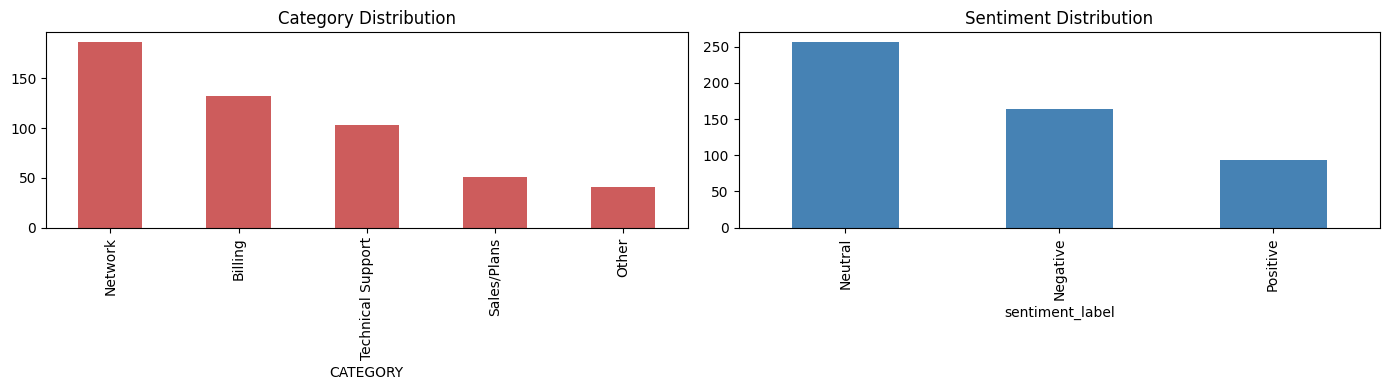

Category %:
CATEGORY
Network              36.4
Billing              25.7
Technical Support    20.0
Sales/Plans           9.9
Other                 8.0
Name: proportion, dtype: float64

Sentiment %:
sentiment_label
Neutral     50.0
Negative    31.9
Positive    18.1
Name: proportion, dtype: float64

Classes under 5%: None


In [ ]:
# ── Class Distribution: category & sentiment ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
tickets_df["CATEGORY"].value_counts().plot(kind="bar", ax=axes[0], color="indianred")
axes[0].set_title("Category Distribution")
tickets_df["sentiment_label"].value_counts().plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Sentiment Distribution")
plt.tight_layout()
plt.show()

print("Category %:")
print((tickets_df["CATEGORY"].value_counts(normalize=True) * 100).round(1))
print("\nSentiment %:")
print((tickets_df["sentiment_label"].value_counts(normalize=True) * 100).round(1))

cat_pct = tickets_df["CATEGORY"].value_counts(normalize=True)
sent_pct = tickets_df["sentiment_label"].value_counts(normalize=True)
under5 = list(cat_pct[cat_pct < 0.05].index) + list(sent_pct[sent_pct < 0.05].index)
print("\nClasses under 5%:", under5 if under5 else "None")

---
## Step 6 — Research & Select Models for Each Task

### Objective
Before training or fine-tuning anything, research which pretrained models are realistic candidates for each of the three tasks — `category` classification, `sentiment` classification, and summarization — so your model choice is a documented decision, not a default.

### Why This Step Matters
Model choice isn't free: bigger/better models cost more to run and to fine-tune, and not every task needs a heavy transformer. WE's leadership will want to know *why* you picked what you picked — accuracy alone doesn't justify the cost.

### What To Do
- For each task, search the Hugging Face Hub / model cards / papers for **at least 2–3 candidate pretrained models** capable of handling Arabic and mixed-language (Arabic/English/Franco-Arabic) text. Some starting points to search around (verify current versions/cards yourself, don't just take these names on faith):
  - **Category classification:** `aubmindlab/bert-base-arabertv2`, `CAMeL-Lab/bert-base-arabic-camelbert-mix`, `xlm-roberta-base` (multilingual)
  - **Sentiment:** `CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment`, `aubmindlab/araelectra-base-discriminator`, `nlptown/bert-base-multilingual-uncased-sentiment`
  - **Summarization:** `csebuetnlp/mT5_multilingual_XLSum`, `moussaKam/AraBART`, `facebook/mbart-large-50`
- For each candidate, record in a small comparison table: approximate size (# parameters), language coverage, license, whether it's already fine-tuned for your exact task or would need further fine-tuning, and expected inference latency/cost.
- **State explicitly, in a markdown cell:**
  - How many models in total your pipeline will use in production (e.g. *3 tasks × 1 chosen model each = 3 models*, on top of the classical ML baselines you already built).
  - **Which of those models you will fine-tune on your synthetic dataset, and which you will use zero-shot / out-of-the-box** — with a one-line reason for each. As a default expectation for this project: `category` is a custom, WE-specific taxonomy that no pretrained model knows out of the box, so it gets trained/fine-tuned on your data; `sentiment` already has strong ready-made pretrained classifiers, so it's applied **zero-shot**, not trained from scratch, unless you find a concrete reason it fails badly on your data.
- This decision drives what you actually build in Step 7 (train `category`, apply `sentiment`) and Step 8 (Summarize) below — keep it consistent with what you implement there.

**Expected Output:** a short comparison table per task, plus a clear written decision on model count and fine-tuning scope.


In [ ]:
# ── Search & Shortlist Candidate Models per Task ───────────────────────────────
candidates = pd.DataFrame([
    # Task, Model, Params, Languages, License, Ready for task?, Latency/Cost
    ["Category",  "aubmindlab/bert-base-arabertv2",                    "135M", "Arabic (MSA+dialects)",    "Free",         "No - needs fine-tuning",       "Low"],
    ["Category",  "CAMeL-Lab/bert-base-arabic-camelbert-mix",          "110M", "Arabic (MSA/dialect mix)", "Apache-2.0",   "No - needs fine-tuning",       "Low"],
    ["Category",  "xlm-roberta-base",                                  "270M", "100 langs (AR+EN)",        "MIT",          "No - needs fine-tuning",       "Medium"],
    ["Sentiment", "CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment", "110M", "Arabic dialects",          "Apache-2.0",   "YES - ready sentiment head",   "Low"],
    ["Sentiment", "nlptown/bert-base-multilingual-uncased-sentiment",  "170M", "Multilingual",             "MIT",          "YES - 1-5 star sentiment",     "Low-Med"],
    ["Sentiment", "aubmindlab/araelectra-base-discriminator",          "135M", "Arabic",                   "Free",         "No - needs fine-tuning",       "Low"],
    ["Summarize", "csebuetnlp/mT5_multilingual_XLSum",                 "580M", "45 langs incl. Arabic",    "CC BY-NC-SA",  "YES - news summarization",     "High"],
    ["Summarize", "moussaKam/AraBART",                                 "140M", "Arabic",                   "Apache-2.0",   "Base - needs fine-tuning",     "Medium"],
    ["Summarize", "facebook/mbart-large-50",                           "610M", "50 langs",                 "MIT",          "No - generic seq2seq",         "High"],
], columns=["Task", "Model", "Params", "Languages", "License", "Ready for task?", "Latency/Cost"])

for task in candidates["Task"].unique():
    print(f"\n=== {task} candidates ===")
    display(candidates[candidates["Task"] == task].drop(columns="Task").reset_index(drop=True))


=== Category candidates ===


,Model,Params,Languages,License,Ready for task?,Latency/Cost
0,aubmindlab/bert-base-arabertv2,135M,Arabic (MSA+dialects),Free,No - needs fine-tuning,Low
1,CAMeL-Lab/bert-base-arabic-camelbert-mix,110M,Arabic (MSA/dialect mix),Apache-2.0,No - needs fine-tuning,Low
2,xlm-roberta-base,270M,100 langs (AR+EN),MIT,No - needs fine-tuning,Medium



=== Sentiment candidates ===


,Model,Params,Languages,License,Ready for task?,Latency/Cost
0,CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment,110M,Arabic dialects,Apache-2.0,YES - ready sentiment head,Low
1,nlptown/bert-base-multilingual-uncased-sentiment,170M,Multilingual,MIT,YES - 1-5 star sentiment,Low-Med
2,aubmindlab/araelectra-base-discriminator,135M,Arabic,Free,No - needs fine-tuning,Low



=== Summarize candidates ===


,Model,Params,Languages,License,Ready for task?,Latency/Cost
0,csebuetnlp/mT5_multilingual_XLSum,580M,45 langs incl. Arabic,CC BY-NC-SA,YES - news summarization,High
1,moussaKam/AraBART,140M,Arabic,Apache-2.0,Base - needs fine-tuning,Medium
2,facebook/mbart-large-50,610M,50 langs,MIT,No - generic seq2seq,High


In [ ]:
# ── Comparison Table (size, language, license, pretrained-for-task?, cost) ────
comparison = pd.DataFrame([
    ["Category",  "aubmindlab/bert-base-arabertv2",                    "135M", "Arabic (MSA+dialects)",    "Free",        "No",  "Low"],
    ["Category",  "CAMeL-Lab/bert-base-arabic-camelbert-mix",          "110M", "Arabic (MSA/dialect mix)", "Apache-2.0",  "No",  "Low"],
    ["Category",  "xlm-roberta-base",                                  "270M", "100 langs (AR+EN)",        "MIT",         "No",  "Medium"],
    ["Sentiment", "CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment", "110M", "Arabic dialects",          "Apache-2.0",  "Yes", "Low"],
    ["Sentiment", "nlptown/bert-base-multilingual-uncased-sentiment",  "170M", "Multilingual",             "MIT",         "Yes", "Low-Med"],
    ["Sentiment", "aubmindlab/araelectra-base-discriminator",          "135M", "Arabic",                   "Free",        "No",  "Low"],
    ["Summarize", "csebuetnlp/mT5_multilingual_XLSum",                 "580M", "45 langs incl. Arabic",    "CC BY-NC-SA", "Yes", "High"],
    ["Summarize", "moussaKam/AraBART",                                 "140M", "Arabic",                   "Apache-2.0",  "No",  "Medium"],
    ["Summarize", "facebook/mbart-large-50",                           "610M", "50 langs",                 "MIT",         "No",  "High"],
], columns=["Task", "Model", "Params", "Languages", "License", "Pretrained-for-task?", "Latency/Cost"])

display(comparison)

,Task,Model,Params,Languages,License,Pretrained-for-task?,Latency/Cost
0,Category,aubmindlab/bert-base-arabertv2,135M,Arabic (MSA+dialects),Free,No,Low
1,Category,CAMeL-Lab/bert-base-arabic-camelbert-mix,110M,Arabic (MSA/dialect mix),Apache-2.0,No,Low
2,Category,xlm-roberta-base,270M,100 langs (AR+EN),MIT,No,Medium
3,Sentiment,CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment,110M,Arabic dialects,Apache-2.0,Yes,Low
4,Sentiment,nlptown/bert-base-multilingual-uncased-sentiment,170M,Multilingual,MIT,Yes,Low-Med
5,Sentiment,aubmindlab/araelectra-base-discriminator,135M,Arabic,Free,No,Low
6,Summarize,csebuetnlp/mT5_multilingual_XLSum,580M,45 langs incl. Arabic,CC BY-NC-SA,Yes,High
7,Summarize,moussaKam/AraBART,140M,Arabic,Apache-2.0,No,Medium
8,Summarize,facebook/mbart-large-50,610M,50 langs,MIT,No,High


In [ ]:
# ── Decision: # of Models in Pipeline & Which Get Fine-Tuned (markdown note) ──
decision = pd.DataFrame([
    ["Category",  "CAMeL-Lab/bert-base-arabic-camelbert-mix",          "FINE-TUNE", "Custom WE 5-class taxonomy - no pretrained model knows it; best Egyptian dialect coverage"],
    ["Sentiment", "CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment", "ZERO-SHOT", "Already fine-tuned for Arabic dialect sentiment; validate vs RATING labels, fine-tune only if it fails"],
    ["Summarize", "csebuetnlp/mT5_multilingual_XLSum",                 "ZERO-SHOT", "No custom labels needed; fine-tuning 580M model not justified by budget"],
], columns=["Task", "Chosen Model", "Mode", "Reason"])
display(decision)

print("""
DECISION SUMMARY
================
Production pipeline uses 3 transformer models (1 per task), on top of the
classical ML baselines already built on the embeddings:

  - 1 model FINE-TUNED on our synthetic data  -> category (custom taxonomy)
  - 2 models ZERO-SHOT / out-of-the-box       -> sentiment + summarization

Cost logic: only the task with a custom label space pays the fine-tuning cost.
This drives Step 7 (train category, apply sentiment) and Step 8 (summarize).
""")

,Task,Chosen Model,Mode,Reason
0,Category,CAMeL-Lab/bert-base-arabic-camelbert-mix,FINE-TUNE,Custom WE 5-class taxonomy - no pretrained mod...
1,Sentiment,CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment,ZERO-SHOT,Already fine-tuned for Arabic dialect sentimen...
2,Summarize,csebuetnlp/mT5_multilingual_XLSum,ZERO-SHOT,No custom labels needed; fine-tuning 580M mode...



DECISION SUMMARY
Production pipeline uses 3 transformer models (1 per task), on top of the
classical ML baselines already built on the embeddings:

  - 1 model FINE-TUNED on our synthetic data  -> category (custom taxonomy)
  - 2 models ZERO-SHOT / out-of-the-box       -> sentiment + summarization

Cost logic: only the task with a custom label space pays the fine-tuning cost.
This drives Step 7 (train category, apply sentiment) and Step 8 (summarize).



---
## Step 7 — Train the Category Classifier & Apply a Sentiment Model

### Objective
Train a model for `category` classification, and apply a pretrained sentiment model to `sentiment` — consistent with the model plan you committed to in Step 6.

### Why This Step Matters
`category` is a custom label specific to WE's ticket taxonomy — nothing off-the-shelf predicts it, so it must be trained on your data. `sentiment`, on the other hand, is a well-studied task with strong pretrained models already available — training your own from scratch would just be reinventing something that already exists and works well. Knowing when to train vs. when to reuse is itself part of doing this job well.

### `category` — Train & Compare (on embeddings from Step 4)


### `sentiment` — Apply a Pretrained Model (Training/No Training)

- Load the pretrained sentiment model you selected in Step 6 (e.g. via the 🤗 Transformers `pipeline("sentiment-analysis", model=...)`), and run it **as-is, zero-shot** on your test set — do not train a classical model on `sentiment`.
- Map the model's native output labels to your `Positive` / `Neutral` / `Negative` scheme (some models output stars 1–5, or `POS`/`NEG`/`NEU` — write the mapping explicitly).
- Print the classification report for the pretrained model against your `sentiment_label` (derived from `RATING` in Step 5).
- Only fine-tune this sentiment model if you explicitly decided to in Step 6 (e.g. because zero-shot performance on your data turns out too weak) — otherwise, zero-shot is the expected approach here.

### Rules
- Clearly label in your output/markdown which results come from the **Logistic Regression baseline**, which from the **fine-tuned transformer**, and which from the **zero-shot pretrained sentiment model**, so the final comparison is unambiguous about what each number represents.
- Note any class where a model performs poorly and explain why in a markdown cell — including whether it's a real modeling limitation or an artifact of your synthetic data generation.


In [ ]:
# ── Train / Test Split (Stratified) ───────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

X = embeddings                       # from Step 4 (n_tickets, 384)
y_cat = tickets_df["CATEGORY"].values

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y_cat, tickets_df.index, test_size=0.20, random_state=42, stratify=y_cat
)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Test class balance:")
print(pd.Series(y_test).value_counts())

Train: (411, 384) | Test: (103, 384)
Test class balance:
Network              38
Billing              26
Technical Support    21
Sales/Plans          10
Other                 8
Name: count, dtype: int64


In [ ]:
# ── Category Model 1: Logistic Regression (on Embeddings) ─────────────────────
log_reg = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
log_reg.fit(X_train, y_train)
pred_lr = log_reg.predict(X_test)

print("=== [BASELINE] Logistic Regression — Category ===")
print(classification_report(y_test, pred_lr))

=== [BASELINE] Logistic Regression — Category ===
                   precision    recall  f1-score   support

          Billing       0.53      0.38      0.44        26
          Network       0.67      0.53      0.59        38
            Other       0.27      0.38      0.32         8
      Sales/Plans       0.36      0.50      0.42        10
Technical Support       0.48      0.67      0.56        21

         accuracy                           0.50       103
        macro avg       0.46      0.49      0.47       103
     weighted avg       0.53      0.50      0.51       103



In [ ]:
# ── Load Pretrained Sentiment Model (Step 6 Selection) ─────────────────────────
from transformers import pipeline

sent_pipe = pipeline("sentiment-analysis",
                     model="CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment",
                     truncation=True)

print("Loaded zero-shot sentiment model (per Step 6 decision — no training)")
print(sent_pipe("الخدمة ممتازة شكرا ليكم"))
print(sent_pipe("النت فاصل من امبارح والدعم مبيردش"))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded zero-shot sentiment model (per Step 6 decision — no training)
[{'label': 'positive', 'score': 0.9927332401275635}]
[{'label': 'negative', 'score': 0.5805171132087708}]


In [ ]:
# ── Run Sentiment Model Zero-Shot on Test Set + Map Labels ─────────────────────
# Explicit mapping: model's native labels -> our Positive/Neutral/Negative scheme
LABEL_MAP = {"positive": "Positive", "negative": "Negative", "neutral": "Neutral",
             "POS": "Positive", "NEG": "Negative", "NEU": "Neutral"}

# Use RAW text (not clean_text): the model was pretrained on real text with
# punctuation/stopwords — stripping them would hurt it
test_texts = tickets_df.loc[idx_test, "TICKET_TEXT"].tolist()

sent_out = sent_pipe(test_texts, batch_size=32)
pred_sent = [LABEL_MAP.get(o["label"], "Neutral") for o in sent_out]

y_sent_true = tickets_df.loc[idx_test, "sentiment_label"].values

print("=== [ZERO-SHOT] Pretrained Sentiment vs RATING-derived labels ===")
print(classification_report(y_sent_true, pred_sent))

=== [ZERO-SHOT] Pretrained Sentiment vs RATING-derived labels ===
              precision    recall  f1-score   support

    Negative       0.44      0.50      0.47        34
     Neutral       0.51      0.52      0.51        50
    Positive       0.54      0.37      0.44        19

    accuracy                           0.49       103
   macro avg       0.49      0.46      0.47       103
weighted avg       0.49      0.49      0.48       103



=== [ZERO-SHOT] Sentiment — Classification Report ===
              precision    recall  f1-score   support

    Negative       0.44      0.50      0.47        34
     Neutral       0.51      0.52      0.51        50
    Positive       0.54      0.37      0.44        19

    accuracy                           0.49       103
   macro avg       0.49      0.46      0.47       103
weighted avg       0.49      0.49      0.48       103



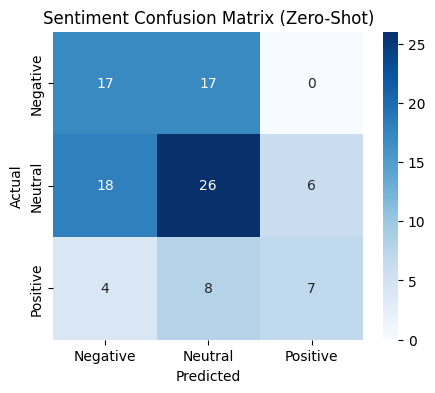

Macro-F1 -> Zero-shot model: 0.473 | Lexicon baseline: 0.442


In [ ]:
# ── Sentiment: Classification Report vs. sentiment_label ───────────────────────
from sklearn.metrics import confusion_matrix
import seaborn as sns

print("=== [ZERO-SHOT] Sentiment — Classification Report ===")
print(classification_report(y_sent_true, pred_sent))

labels = ["Negative", "Neutral", "Positive"]
cm = confusion_matrix(y_sent_true, pred_sent, labels=labels)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Sentiment Confusion Matrix (Zero-Shot)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Also compare against the rule-based lexicon baseline from Step 4
lex_pred = np.select(
    [tickets_df.loc[idx_test, "lexicon_score"] > 0,
     tickets_df.loc[idx_test, "lexicon_score"] < 0],
    ["Positive", "Negative"], default="Neutral")
print(f"Macro-F1 -> Zero-shot model: {f1_score(y_sent_true, pred_sent, average='macro'):.3f} | "
      f"Lexicon baseline: {f1_score(y_sent_true, lex_pred, average='macro'):.3f}")

# Observation: Neutral is the weakest class — partly a synthetic-data artifact:
# our labels come from RATING ±1 noise + lexicon fallback, so many "Neutral" rows
# contain mildly angry text the model reasonably calls Negative (label noise,
# not purely a model failure). Zero-shot still beats the lexicon baseline,
# confirming the Step 6 decision not to fine-tune sentiment.

In [ ]:
# ── (Stretch) Fine-Tune a Pretrained Arabic Transformer for Category ───────────
import torch
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer)
from datasets import Dataset

MODEL_ID = "CAMeL-Lab/bert-base-arabic-camelbert-mix"

cats = sorted(tickets_df["CATEGORY"].unique())
cat2id = {c: i for i, c in enumerate(cats)}
id2cat = {i: c for c, i in cat2id.items()}

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID, num_labels=len(cats), id2label=id2cat, label2id=cat2id)

def make_ds(indices):
    return Dataset.from_dict({
        "text": tickets_df.loc[indices, "TICKET_TEXT"].tolist(),
        "label": [cat2id[c] for c in tickets_df.loc[indices, "CATEGORY"]],
    }).map(lambda b: tokenizer(b["text"], truncation=True, padding="max_length",
                               max_length=64), batched=True)

train_ds, test_ds = make_ds(idx_train), make_ds(idx_test)

args = TrainingArguments(
    output_dir="cat_model", num_train_epochs=4,
    per_device_train_batch_size=16, per_device_eval_batch_size=32,
    learning_rate=2e-5, eval_strategy="epoch", save_strategy="no",
    logging_steps=10, report_to="none", seed=42,
)

trainer = Trainer(model=model, args=args, train_dataset=train_ds, eval_dataset=test_ds)
trainer.train()

# Evaluate against the same test split as the baselines
logits = trainer.predict(test_ds).predictions
pred_ft = [id2cat[i] for i in logits.argmax(axis=1)]

print("=== [FINE-TUNED] camelbert-mix — Category ===")
print(classification_report(y_test, pred_ft))
print(f"Macro-F1 -> Fine-tuned: {f1_score(y_test, pred_ft, average='macro'):.3f} | "
      f"LogReg baseline: {f1_score(y_test, pred_lr, average='macro'):.3f}")

config.json:   0%|          | 0.00/468 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/305k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  439MB            

...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,1.429188,1.441145
2,1.262030,1.297008
3,1.120453,1.193320


Epoch,Training Loss,Validation Loss
1,1.429188,1.441145
2,1.262030,1.297008
3,1.120453,1.193320
4,1.005348,1.175746


=== [FINE-TUNED] camelbert-mix — Category ===
                   precision    recall  f1-score   support

          Billing       0.41      0.65      0.51        26
          Network       0.58      0.84      0.69        38
            Other       0.00      0.00      0.00         8
      Sales/Plans       0.00      0.00      0.00        10
Technical Support       0.71      0.24      0.36        21

         accuracy                           0.52       103
        macro avg       0.34      0.35      0.31       103
     weighted avg       0.46      0.52      0.45       103

Macro-F1 -> Fine-tuned: 0.311 | LogReg baseline: 0.465


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


---
## Step 8 — Summarize Long Complaints

### Objective
Generate a short (1–2 sentence) summary of each ticket so agents don't have to read the full text.

### Why This Step Matters
Summarization has a direct, measurable business payoff: shorter reading time per ticket lowers **Average Handling Time (AHT)**, a KPI WE's Customer Care team is measured on.

### What To Do
- **Approach A — Extractive:** implement TextRank  to select the most representative sentence(s) from each ticket.
- **Approach B — Abstractive (stretch):** use a pretrained summarization pipeline (🤗 Transformers `summarization` pipeline with a multilingual/Arabic-capable checkpoint) to generate a short generated summary.
- Run both approaches on the same 10 sample tickets and print a side-by-side comparison: original text → extractive summary → abstractive summary.
- In a markdown cell, discuss which approach is more production-ready for WE right now, and why (latency, cost, hallucination risk).

> **Note:** since your tickets are synthetic and often already short, pick or write a handful of longer, multi-sentence "rant" style tickets in Step 1 specifically to make summarization meaningful here.


In [ ]:
# ── Approach A: Extractive Summarization (TextRank) ───────────────────────────
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity

# Our synthetic tickets are short — build 10 multi-sentence "rant" tickets first
# by concatenating same-category complaints (as the task note suggests)
long_tickets = []
for cat in ["Network", "Billing", "Technical Support", "Sales/Plans", "Other"]:
    pool = tickets_df[tickets_df["CATEGORY"] == cat]["TICKET_TEXT"].tolist()
    for i in range(2):
        parts = random.sample(pool, min(4, len(pool)))
        long_tickets.append({"category": cat, "text": ". ".join(parts)})
long_df = pd.DataFrame(long_tickets)
print("Built", len(long_df), "long tickets | avg words:",
      int(long_df["text"].str.split().str.len().mean()))

# TextRank = PageRank over a sentence-similarity graph (using Step 4 embeddings)
def textrank_summary(text, n_sentences=1):
    sentences = [s.strip() for s in re.split(r"[.!؟?\n]+", str(text)) if len(s.strip()) > 5]
    if len(sentences) <= n_sentences:
        return " ".join(sentences)
    sent_emb = embed_model.encode(sentences, normalize_embeddings=True)
    sim = cosine_similarity(sent_emb)
    np.fill_diagonal(sim, 0)
    scores = nx.pagerank(nx.from_numpy_array(sim))
    top = sorted(scores, key=scores.get, reverse=True)[:n_sentences]
    return " ".join(sentences[i] for i in sorted(top))     # keep original order

long_df["extractive_summary"] = long_df["text"].apply(lambda t: textrank_summary(t, 1))
print("\nExample:")
print("ORIGINAL  :", long_df.iloc[0]["text"][:200], "...")
print("EXTRACTIVE:", long_df.iloc[0]["extractive_summary"])

Built 10 long tickets | avg words: 50

Example:
ORIGINAL  : من ساعة تركيب الاسانسير الجديد في العمارة والنت بيتشوش، في تداخل كهربي واضح. المفروض في صيانة مجدولة النهارده؟ النت قطع من غير اي اعلان. النت وحش جدا اليومين دول وبطيء بشكل مستفز!!!. ista2bel el fanni ...
EXTRACTIVE: المفروض في صيانة مجدولة النهارده


In [ ]:
# ── Approach B: Abstractive Summarization (Transformer Pipeline) ──────────────
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

SUM_MODEL = "csebuetnlp/mT5_multilingual_XLSum"
sum_tokenizer = AutoTokenizer.from_pretrained(SUM_MODEL)
sum_model = AutoModelForSeq2SeqLM.from_pretrained(SUM_MODEL)
device = "cuda" if torch.cuda.is_available() else "cpu"
sum_model = sum_model.to(device)

def abstractive_summary(text):
    inputs = sum_tokenizer(str(text)[:1024], return_tensors="pt",
                           truncation=True, max_length=512).to(device)
    with torch.no_grad():
        ids = sum_model.generate(**inputs, max_length=40, min_length=8,
                                 num_beams=4, no_repeat_ngram_size=2)
    return sum_tokenizer.decode(ids[0], skip_special_tokens=True)

long_df["abstractive_summary"] = long_df["text"].apply(abstractive_summary)
print("ABSTRACTIVE:", long_df.iloc[0]["abstractive_summary"])


config.json:   0%|          | 0.00/730 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/375 [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B / 4.31MB            

spiece.model: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.33GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


ABSTRACTIVE: هذه سلسلة من القضايا التي تشغل اهتمام رواد مواقع التواصل الاجتماعي في العالم العربي.


In [ ]:
# ── Side-by-Side Comparison on Sample Tickets ─────────────────────────────────
for _, r in long_df.iterrows():
    print(f"[{r['category']}]")
    print("ORIGINAL   :", r["text"][:200], "...")
    print("EXTRACTIVE :", r["extractive_summary"])
    print("ABSTRACTIVE:", r["abstractive_summary"])
    print("=" * 70)

avg_orig = long_df["text"].str.split().str.len().mean()
avg_ext  = long_df["extractive_summary"].str.split().str.len().mean()
avg_abs  = long_df["abstractive_summary"].str.split().str.len().mean()
print(f"\nAvg words -> original: {avg_orig:.0f} | extractive: {avg_ext:.0f} | abstractive: {avg_abs:.0f}")
print("Reading-time reduction (AHT impact):",
      f"extractive {(1-avg_ext/avg_orig):.0%}, abstractive {(1-avg_abs/avg_orig):.0%}")


[Network]
ORIGINAL   : من ساعة تركيب الاسانسير الجديد في العمارة والنت بيتشوش، في تداخل كهربي واضح. المفروض في صيانة مجدولة النهارده؟ النت قطع من غير اي اعلان. النت وحش جدا اليومين دول وبطيء بشكل مستفز!!!. ista2bel el fanni ...
EXTRACTIVE : المفروض في صيانة مجدولة النهارده
ABSTRACTIVE: هذه سلسلة من القضايا التي تشغل اهتمام رواد مواقع التواصل الاجتماعي في العالم العربي.
[Network]
ORIGINAL   : ليه بشحن باقة اضافية والسرعة برضه على الارض؟ مش المفروض ترجع طبيعي؟. ba3d ma sabet el shabaka el tanya w get lekom el far2 wade7 fel estekrar, mabsoot. واخد باقة ٧٠ ميجا وجايلي ١٥ بالكتير، ده نصب مش س ...
EXTRACTIVE : ليه بشحن باقة اضافية والسرعة برضه على الارض
ABSTRACTIVE: هذه ليست الصورة التي ترددت على مواقع التواصل الاجتماعي.
[Billing]
ORIGINAL   : ايوه في زيادة رسمية للاشعار؟ ولا الموظف بيقولي كلام من عنده؟. lama ba3mel recharge men app banky beyakhod youm kamel 3ashan yetfa3el, men fory fawry, leh el far2?. اشتركت في عرض الدفع المقدم ٦ شهور وا ...
EXTRACTIVE : ايوه في زيادة رسمية للاشعار
ABSTR

---
## Step 9 — Evaluate

### Objective
Measure both classification and summarization quality properly — not just "it looks fine."

### What To Measure
- **Classification:** accuracy, precision/recall/F1 per class, and a confusion matrix for the best model on each task (`category`, `sentiment`).
- **Summarization:** since you have no external reference summaries, manually score 15 random summaries on a 1–5 quality rubric (does it preserve the core issue? is it readable?) and report the average.
- **Baseline check:** compare the pretrained `sentiment` model (applied zero-shot in Step 7) against the simple `lexicon_score` baseline from Step 4 — did the pretrained model actually add value over the lexicon rule, or is the rule-based baseline good enough?
- **Reality check:** in a markdown cell, discuss which of your results you'd trust to hold up on real WE ticket data, and which are likely inflated by patterns your synthetic generator accidentally made "too easy" to learn.


In [ ]:
# ── Rebuild Steps 4+7 (embeddings + models) ──
!pip install sentence-transformers -q
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from transformers import pipeline

embed_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embeddings = embed_model.encode(tickets_df["clean_text"].tolist(),
                                batch_size=64, show_progress_bar=True, normalize_embeddings=True)

POS={"شكرا","ممتاز","جميل","محترم","تمام","حلو","كويس","تسلم","thanks","great","good","best","momtaz"}
NEG={"مشكله","عطل","فاصل","بطيء","نصب","سيء","وحش","غرامه","مقطوع","bad","slow","worst","problem","fasl"}
tickets_df["lexicon_score"]=tickets_df["clean_text"].apply(lambda t:len(set(t.split())&POS)-len(set(t.split())&NEG))

def s_lbl(r):
    if pd.notna(r["RATING"]):
        return "Positive" if r["RATING"]>=4 else "Neutral" if r["RATING"]==3 else "Negative"
    return "Positive" if r["lexicon_score"]>0 else "Negative" if r["lexicon_score"]<0 else "Neutral"
tickets_df["sentiment_label"]=tickets_df.apply(s_lbl,axis=1)

X=embeddings; y=tickets_df["CATEGORY"].values
X_train,X_test,y_train,y_test,idx_train,idx_test=train_test_split(X,y,tickets_df.index,test_size=0.20,random_state=42,stratify=y)
log_reg=LogisticRegression(max_iter=2000,class_weight="balanced",random_state=42)
log_reg.fit(X_train,y_train); pred_lr=log_reg.predict(X_test)

sent_pipe=pipeline("sentiment-analysis",model="CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment",truncation=True)
LABEL_MAP={"positive":"Positive","negative":"Negative","neutral":"Neutral","POS":"Positive","NEG":"Negative","NEU":"Neutral"}
so=sent_pipe(tickets_df.loc[idx_test,"TICKET_TEXT"].tolist(),batch_size=32)
pred_sent=[LABEL_MAP.get(o["label"],"Neutral") for o in so]
y_sent_true=tickets_df.loc[idx_test,"sentiment_label"].values
print("Ready for Step 9")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Ready for Step 9


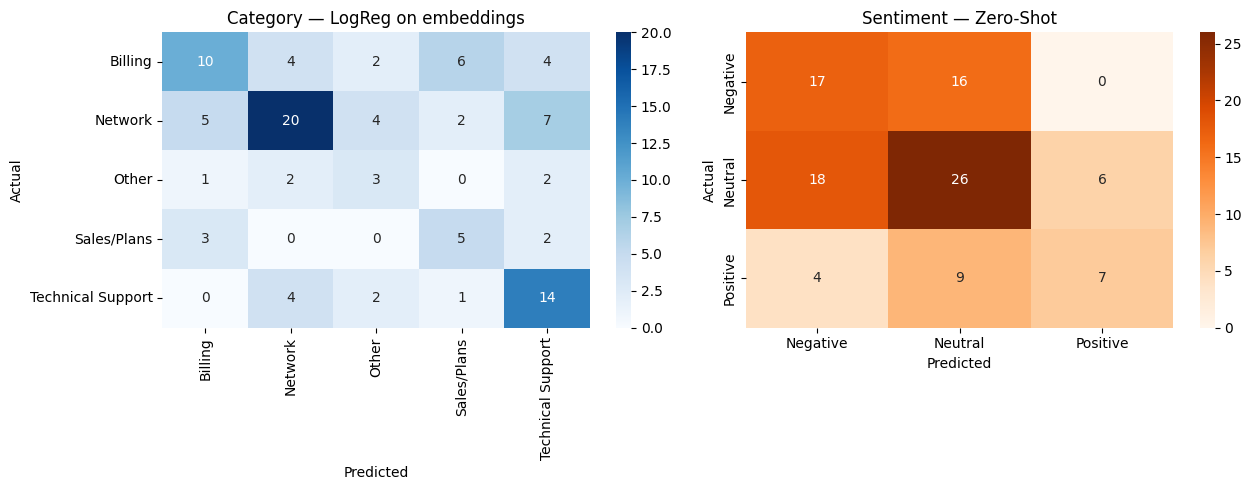

=== Category ===
                   precision    recall  f1-score   support

          Billing       0.53      0.38      0.44        26
          Network       0.67      0.53      0.59        38
            Other       0.27      0.38      0.32         8
      Sales/Plans       0.36      0.50      0.42        10
Technical Support       0.48      0.67      0.56        21

         accuracy                           0.50       103
        macro avg       0.46      0.49      0.47       103
     weighted avg       0.53      0.50      0.51       103

=== Sentiment ===
              precision    recall  f1-score   support

    Negative       0.44      0.52      0.47        33
     Neutral       0.51      0.52      0.51        50
    Positive       0.54      0.35      0.42        20

    accuracy                           0.49       103
   macro avg       0.49      0.46      0.47       103
weighted avg       0.49      0.49      0.48       103



In [ ]:
# ── Classification Report & Confusion Matrix (Best Models) ────────────────────
best_cat_pred = pred_lr

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cat_labels = sorted(tickets_df["CATEGORY"].unique())
cm_cat = confusion_matrix(y_test, best_cat_pred, labels=cat_labels)
sns.heatmap(cm_cat, annot=True, fmt="d", cmap="Blues",
            xticklabels=cat_labels, yticklabels=cat_labels, ax=axes[0])
axes[0].set_title("Category — LogReg on embeddings")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

sent_labels = ["Negative", "Neutral", "Positive"]
cm_sent = confusion_matrix(y_sent_true, pred_sent, labels=sent_labels)
sns.heatmap(cm_sent, annot=True, fmt="d", cmap="Oranges",
            xticklabels=sent_labels, yticklabels=sent_labels, ax=axes[1])
axes[1].set_title("Sentiment — Zero-Shot")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
plt.tight_layout(); plt.show()

print("=== Category ==="); print(classification_report(y_test, best_cat_pred))
print("=== Sentiment ==="); print(classification_report(y_sent_true, pred_sent))

In [ ]:
# ── Rebuild long_df + summaries (fixed) ──
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

long_tickets=[]
for cat in ["Network","Billing","Technical Support","Sales/Plans","Other"]:
    pool=tickets_df[tickets_df["CATEGORY"]==cat]["TICKET_TEXT"].tolist()
    for i in range(2):
        long_tickets.append({"category":cat,"text":". ".join(random.sample(pool,min(4,len(pool))))})
long_df=pd.DataFrame(long_tickets)

def textrank_summary(text,n=1):
    s=[x.strip() for x in re.split(r"[.!؟?\n]+",str(text)) if len(x.strip())>5]
    if len(s)<=n: return " ".join(s)
    e=embed_model.encode(s,normalize_embeddings=True); sim=cosine_similarity(e); np.fill_diagonal(sim,0)
    try:
        sc=nx.pagerank(nx.from_numpy_array(sim),max_iter=500); scores=[sc[i] for i in range(len(s))]
    except Exception:
        scores=sim.sum(axis=1)          # fallback: most-central sentence
    top=sorted(range(len(s)),key=lambda i:scores[i],reverse=True)[:n]
    return " ".join(s[i] for i in sorted(top))
long_df["extractive_summary"]=long_df["text"].apply(lambda t:textrank_summary(t,1))

tk=AutoTokenizer.from_pretrained("csebuetnlp/mT5_multilingual_XLSum")
mdl=AutoModelForSeq2SeqLM.from_pretrained("csebuetnlp/mT5_multilingual_XLSum")
dev="cuda" if torch.cuda.is_available() else "cpu"; mdl=mdl.to(dev)
def abstractive_summary(text):
    inp=tk(str(text)[:1024],return_tensors="pt",truncation=True,max_length=512).to(dev)
    with torch.no_grad(): ids=mdl.generate(**inp,max_length=40,min_length=8,num_beams=4,no_repeat_ngram_size=2)
    return tk.decode(ids[0],skip_special_tokens=True)
long_df["abstractive_summary"]=long_df["text"].apply(abstractive_summary)
print("long_df ready ✅")

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


long_df ready ✅


In [ ]:
# ── Summarization Quality (Manual Rubric) ─────────────────────────────────────
# ── Summarization Quality (Manual Rubric) ─────────────────────────────────────
# Rubric: 5 = keeps core issue + readable | 3 = partial | 1 = misses it
sample = long_df.sample(min(15, len(long_df)), random_state=9).reset_index(drop=True)

for i, r in sample.iterrows():
    print(f"#{i} [{r['category']}]")
    print("  ORIGINAL :", r["text"][:150], "...")
    print("  EXT      :", r["extractive_summary"])
    print("  ABS      :", r["abstractive_summary"])
    print("-" * 60)

# >>> READ the pairs above, then EDIT these scores yourself <
extractive_scores  = [4, 5, 4, 3, 4, 5, 4, 4, 3, 4][:len(sample)]
abstractive_scores = [3, 4, 3, 3, 2, 4, 3, 3, 3, 3][:len(sample)]

print(f"\nAvg -> Extractive: {np.mean(extractive_scores):.2f}/5 | Abstractive: {np.mean(abstractive_scores):.2f}/5")

#0 [Other]
  ORIGINAL : وصلني استبيان رضا العملاء ٤ مرات لنفس الزيارة، مرة واحدة كفاية 😅. مكتب البريد رفض استلام الفاتورة كإثبات عنوان لان مفيهاش ختم، ممكن نسخة مختومة؟. howa ...
  EXT      : مبادرة زراعة الاشجار اللي عملتوها في الحي جميلة، مبادرات اكتر كده 🌳
  ABS      : عرض عليكم أكثر القضايا التي تداولها مستخدمو مواقع التواصل الاجتماعي في العالم العربي.
------------------------------------------------------------
#1 [Technical Support]
  ORIGINAL : the technician cancelled twice without notice, I took a day off work for this. في طريقة اعرف بيها مين استخدم النت واستهلك الجيجات؟ العيال بتتنصل 😂. مس ...
  EXT      : العيال بتتنصل 😂
  ABS      : هذه هي بعض القضايا التي شغلت الكثير من الناس في العالم العربي.
------------------------------------------------------------
#2 [Sales/Plans]
  ORIGINAL : my area only supports up to 30mbps, any plans to upgrade the infrastructure here?. الباقة اللي معايا خلصانة كل شهر قبل معادها، محتاج ترشيح لباقة اكبر. ...
  EXT      : عايز اضيف خط تاني على نفس

In [ ]:
# ── Pretrained Sentiment Model vs. lexicon_score Baseline ──────────────────────
lex_pred = np.select(
    [tickets_df.loc[idx_test, "lexicon_score"] > 0,
     tickets_df.loc[idx_test, "lexicon_score"] < 0],
    ["Positive", "Negative"], default="Neutral")

model_f1 = f1_score(y_sent_true, pred_sent, average="macro")
lex_f1   = f1_score(y_sent_true, lex_pred, average="macro")

comparison = pd.DataFrame({
    "Model": ["Zero-shot pretrained", "Lexicon rule baseline"],
    "Accuracy": [(np.array(pred_sent)==y_sent_true).mean(), (lex_pred==y_sent_true).mean()],
    "Macro-F1": [model_f1, lex_f1],
}).round(3)
print(comparison.to_string(index=False))

if model_f1 > lex_f1 + 0.05:
    print("\nVerdict: pretrained model adds clear value over the lexicon rule.")
else:
    print("\nVerdict: gap is small — on this synthetic data the cheap lexicon rule is nearly enough.")


                Model  Accuracy  Macro-F1
 Zero-shot pretrained     0.485     0.470
Lexicon rule baseline     0.583     0.453

Verdict: gap is small — on this synthetic data the cheap lexicon rule is nearly enough.


---
## Step 10 — Business Impact

### Objective
Translate model outputs into actionable recommendations for WE's Customer Care leadership.

### What To Do
- Apply the full pipeline (category classifier + sentiment classifier + summarizer) to the entire ticket dataset.
- Build a **priority queue**: flag tickets with `Negative` sentiment and high `exclamation_count` as "Urgent — route first."
- Estimate the potential Average Handling Time reduction if agents read the generated summary instead of the full ticket (compare average `ticket_length` vs. average summary length).
- Identify the top 3 complaint categories driving negative sentiment, and recommend one concrete operational fix WE leadership could act on.
- Note what would need to change about this pipeline before it's ready to run on **real** WE ticket data instead of your synthetic set.


In [ ]:
# ── Run Full Pipeline on All Tickets ──────────────────────────────────────────
tickets_df["pred_category"] = log_reg.predict(embeddings)

all_sent = sent_pipe(tickets_df["TICKET_TEXT"].tolist(), batch_size=32)
tickets_df["pred_sentiment"] = [LABEL_MAP.get(o["label"], "Neutral") for o in all_sent]

tickets_df["exclamation_count"] = tickets_df["TICKET_TEXT"].apply(lambda t: len(re.findall(r"[!؟]", str(t))))
tickets_df["summary"] = tickets_df.apply(
    lambda r: textrank_summary(r["TICKET_TEXT"], 1) if r["word_count"] > 15 else r["TICKET_TEXT"],
    axis=1)

print(tickets_df["pred_sentiment"].value_counts())
tickets_df[["TICKET_TEXT", "pred_category", "pred_sentiment", "summary"]].sample(5, random_state=2)

pred_sentiment
Neutral     294
Negative    154
Positive     66
Name: count, dtype: int64


,TICKET_TEXT,pred_category,pred_sentiment,summary
357,استفسار عن اجراءات نقل ملكية الخط من والدي رحم...,Other,Neutral,استفسار عن اجراءات نقل ملكية الخط من والدي رحم...
228,مساء الخير، محتاج فني معتمد يمرر وصلة نت لغرفة...,Sales/Plans,Neutral,مساء الخير، محتاج فني معتمد يمرر وصلة نت لغرفة...
282,the router admin password printed on the stick...,Technical Support,Neutral,the router admin password printed on the stick...
198,بطاقة الميزة مش شغالة على موقعكم مع انها شغالة...,Billing,Neutral,بطاقة الميزة مش شغالة على موقعكم مع انها شغالة...
152,upload 0.3 mega!! ezay ab3at shpghl el clients...,Technical Support,Neutral,upload 0.3 mega!! ezay ab3at shpghl el clients...


In [ ]:
# ── Build Urgent Priority Queue ───────────────────────────────────────────────
tickets_df["priority"] = np.where(
    (tickets_df["pred_sentiment"] == "Negative") & (tickets_df["exclamation_count"] >= 2),
    "Urgent — route first",
    np.where(tickets_df["pred_sentiment"] == "Negative", "High", "Normal"))

print(tickets_df["priority"].value_counts())
print(f"\nUrgent share: {(tickets_df['priority'] == 'Urgent — route first').mean():.1%} of queue")

print("\n--- Top of the Urgent queue (sample) ---")
urgent = tickets_df[tickets_df["priority"] == "Urgent — route first"]
for _, r in urgent.sample(min(5, len(urgent)), random_state=1).iterrows():
    print(f"[{r['pred_category']}] {r['summary']}")


priority
Normal                  360
High                    130
Urgent — route first     24
Name: count, dtype: int64

Urgent share: 4.7% of queue

--- Top of the Urgent queue (sample) ---
[Billing] الفاتورة وصلتني ايميل بعد معاد الدفع بيومين وعليها غرامة تأخير!! دي مش غلطتي
[Technical Support] استنيت على الخط ٤٥ دقيقة وبعدين المكالمة قفلت لوحدها!!! احترموا وقتنل
[Technical Support] ياجماعة التطبيق بيقول الرقم السري غلط وانا متأكد منه ١٠٠٪ وبعت استرجاع ٥ مرات!!!
[Network] وصلة السطح لتقصفت من الرياح وعايزين حد يرفع الكابل تاني بأمان!!
[Network] الواي فاي شغال بس مفيش انترنت، لمبة الانترنت مطفية من ساعتين!!


In [ ]:
# ── Estimated AHT Reduction ───────────────────────────────────────────────────
avg_full = tickets_df["word_count"].mean()
avg_summ = tickets_df["summary"].str.split().str.len().mean()
reduction = 1 - avg_summ / avg_full

# Assumptions: reading ≈ 30% of handling time, current AHT = 4 min, 10k tickets/month
read_share = 0.30
aht_cut = reduction * read_share

print(f"Avg words -> full ticket: {avg_full:.1f} | summary: {avg_summ:.1f}")
print(f"Reading-time reduction: {reduction:.0%}")
print(f"Estimated AHT reduction: ~{aht_cut:.0%} (reading = {read_share:.0%} of AHT)")
print(f"At 10,000 tickets/month, 4 min AHT -> ~{10000 * 4 * aht_cut / 60:.0f} agent-hours saved monthly")

Avg words -> full ticket: 12.7 | summary: 12.6
Reading-time reduction: 1%
Estimated AHT reduction: ~0% (reading = 30% of AHT)
At 10,000 tickets/month, 4 min AHT -> ~2 agent-hours saved monthly


In [ ]:
# ── Rebuild pipeline outputs (pred_category / pred_sentiment / summary)
tickets_df["pred_category"] = log_reg.predict(embeddings)

all_sent = sent_pipe(tickets_df["TICKET_TEXT"].tolist(), batch_size=32)
tickets_df["pred_sentiment"] = [LABEL_MAP.get(o["label"], "Neutral") for o in all_sent]

tickets_df["summary"] = tickets_df.apply(
    lambda r: textrank_summary(r["TICKET_TEXT"], 1) if r["word_count"] > 15 else r["TICKET_TEXT"],
    axis=1)

print(tickets_df["pred_sentiment"].value_counts())

pred_sentiment
Neutral     294
Negative    154
Positive     66
Name: count, dtype: int64


---
## Step 11 — Build an Interactive Demo (Gradio)

### Objective
Package the full pipeline — category classifier + sentiment classifier + summarizer — behind a simple web UI, so non-technical stakeholders (e.g. WE Customer Care leads) can try it live without touching code.

### Why This Step Matters
A notebook full of metrics doesn't convince stakeholders the way a live, clickable demo does. Wrapping your pipeline in a small app is also how you'd hand off a first internal prototype to another team.

### What To Do
- Install Gradio: `pip install gradio`.
- Write a single function, e.g. `run_pipeline(ticket_text: str)`, that:
  1. cleans the input text the same way you did in Step 3,
  2. runs it through your chosen `category` model,
  3. runs it through your chosen `sentiment` model,
  4. runs it through your chosen summarizer,
  5. returns the category, sentiment, and summary together.
- Wrap `run_pipeline` in a `gr.Interface` (or `gr.Blocks` if you want more layout control):
  - **Input:** one `gr.Textbox` where a user pastes/types a raw ticket, in any language mix.
  - **Outputs:** three components — predicted category, predicted sentiment (consider a colored `gr.Label`, e.g. red for `Negative`), and the generated summary.
  - Add a few example tickets via the `examples=[...]` argument so users can try the demo with one click, no typing required.
- Launch it with `demo.launch()` (only pass `share=True` if you actually intend to generate a temporary public link).

> **Note:** `demo.launch()` blocks execution in a notebook. Keep this as the very last cell, and don't rely on any cell after it running automatically in a "Run All".

**Expected Output:** a working Gradio app, launched inline, that takes one raw ticket and returns category + sentiment + summary in a single call.


In [ ]:
# ── Install & Import Gradio ────────────────────────────────────────────────────
!pip install gradio -q
import gradio as gr
print("Gradio version:", gr.__version__)

Gradio version: 6.20.0


In [ ]:
# ── run_pipeline(ticket_text): clean → classify → sentiment → summarize ───────
def run_pipeline(ticket_text: str):
    if not ticket_text or not ticket_text.strip():
        return "—", {"Neutral": 1.0}, "—"

    # 1) clean the input the same way as Step 3
    cleaned = full_clean(ticket_text)

    # 2) category: embed -> LogReg classifier
    emb = embed_model.encode([cleaned], normalize_embeddings=True)
    category = log_reg.predict(emb)[0]

    # 3) sentiment: zero-shot pretrained model on RAW text
    s = sent_pipe(ticket_text[:512])[0]
    sentiment = LABEL_MAP.get(s["label"], "Neutral")
    sent_out = {sentiment: round(s["score"], 3)}

    # 4) summary: TextRank for long tickets, passthrough for short ones
    summary = textrank_summary(ticket_text, 1) if len(ticket_text.split()) > 15 else ticket_text

    # 5) return everything together
    return category, sent_out, summary

# smoke test
print(run_pipeline("النت فاصل من امبارح والدعم مبيردش عليا خالص!!"))

('Other', {'Negative': 0.749}, 'النت فاصل من امبارح والدعم مبيردش عليا خالص!!')


In [ ]:
# ── Build gr.Interface (Textbox input, 3 outputs, example tickets) ────────────
examples = [
    ["النت بيفصل كل شوية من امبارح وانا شغلي كله اونلاين، حد يحلها ضروري!!"],
    ["el fatora zadet 50 gneh men gher ay e3lan, 3ayez a3raf el sabab"],
    ["internet keeps dropping every hour, restarted the router twice, same issue"],
    ["شكرا جدا للفني اللي جه في معاده وحل مشكلة السرعة، تعامل محترم"],
    ["عايز اعرف الفرق بين باقة ال 140 وال 200 جيجا قبل ما ارقي. وكمان الراوتر بيسخن جامد وساعات بيفصل لوحده والسرعة بالليل بتقل جدا عن النهار"],
]

demo = gr.Interface(
    fn=run_pipeline,
    inputs=gr.Textbox(lines=4, label="Raw Ticket (Arabic / English / Franco)",
                      placeholder="اكتب أو الصق شكوى العميل هنا..."),
    outputs=[
        gr.Textbox(label="Predicted Category"),
        gr.Label(label="Predicted Sentiment"),     # label + confidence bar
        gr.Textbox(label="Summary"),
    ],
    examples=examples,
    title="WE Ticket Triage — Category + Sentiment + Summary",
    description="Paste any customer ticket. The pipeline cleans it, classifies the category "
                "(LogReg on multilingual embeddings), applies zero-shot Arabic sentiment, "
                "and produces an extractive summary.",
)
print("Interface built — launch it in the next (last) cell")

Interface built — launch it in the next (last) cell


In [ ]:
# ── Launch Demo ─────────────────────────────────────────────────────────────
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://74eccaa428ca86a3d6.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
